In [1]:
from classy import Class
import numpy as np
import matplotlib.pyplot as plt

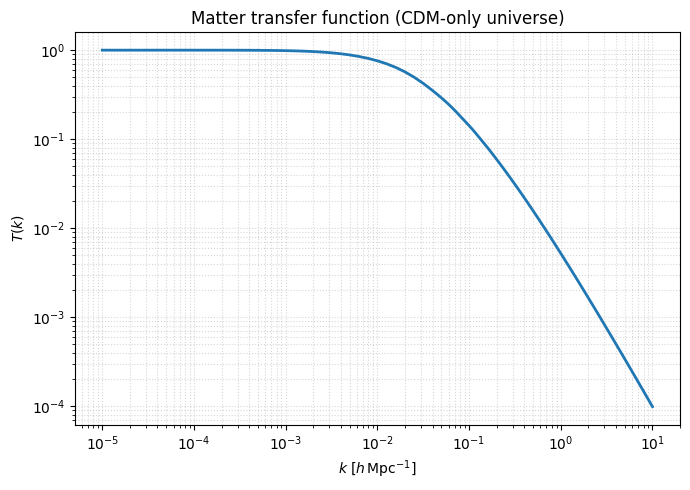

In [2]:
# CDM-only universe.
# CLASS cannot run with Omega_b exactly 0 (it needs nonzero photons and
# baryons), so we use a tiny baryon fraction to approximate a CDM-only cosmology.
# With such a small Omega_b, CLASS can't get the helium fraction from its BBN
# table, so we fix YHe directly instead (as the CLASS error message suggests).
params = {
    "output": "mTk",          # matter (density) transfer functions
    "P_k_max_h/Mpc": 10.0,    # max k for the transfer sampling
    "z_pk": 0.0,              # redshift
    "h": 0.67,
    "Omega_cdm": 0.27,
    "Omega_b": 0.01,          # ~0: as small as CLASS reliably allows
    "A_s": 2.1e-9,
    "n_s": 0.965,
    "YHe": 0.25,
    "tau_reio": 0.06,
}

# Initialize and run CLASS
cosmo = Class()
cosmo.set(params)
cosmo.compute()

# Density transfer functions at z = 0
tk = cosmo.get_transfer(z=0)
k = tk["k (h/Mpc)"]           # wavenumber in h/Mpc
d_tot = tk["d_tot"]           # total matter density transfer (delta_m)

# Matter transfer function T(k):
# on large scales delta_m ~ k^2 * T(k), so define T(k) = delta_m / k^2
# and normalize so that T -> 1 as k -> 0.
T = np.abs(d_tot) / k**2
T /= T[0]

# Plot
plt.figure(figsize=(7, 5))
plt.loglog(k, T, lw=2)
plt.xlabel(r"$k \ [h\,\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$T(k)$")
plt.title("Matter transfer function (CDM-only universe)")
plt.grid(True, which="both", ls=":", alpha=0.5)
plt.tight_layout()
plt.show()

# Clean up CLASS internals
cosmo.struct_cleanup()
cosmo.empty()